In [1]:
from typing import TypedDict, List
from langgraph.graph import StateGraph

In [2]:
class AgentState(TypedDict):
    name: str
    age: int
    skills: List[str]
    final: str

In [3]:
def name_node(state: AgentState) -> AgentState:
    name = state['name']

    state['final'] = f'{name}, welcome to the system! '
    return state

def age_node(state: AgentState) -> AgentState:
    age = state['age']

    state['final'] += f'You are {age} years old! '
    return state

def skills_node(state: AgentState) -> AgentState:
    skills = state['skills']

    if len(skills) == 1:
        skills_str = skills[0]
    else:
        skills_str = ', '.join(skills[:-1]) + f', and {skills[-1]}'

    state['final'] += f'You have skills in: {skills_str}'
    return state


In [4]:
graph = StateGraph(AgentState)

graph.add_node('name_node', name_node)
graph.add_node('age_node', age_node)
graph.add_node('skills_node', skills_node)

graph.set_entry_point('name_node')
graph.add_edge('name_node', 'age_node')
graph.add_edge('age_node', 'skills_node')
graph.set_finish_point('skills_node')

app = graph.compile()

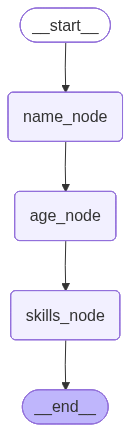

In [5]:
from IPython.display import Image, display

display(Image(app.get_graph().draw_mermaid_png()))

In [7]:
result = app.invoke({'name': 'Le', 'age': 30, 'skills': ['Python', 'Langgraph', 'RAG']})
print(result['final'])

Le, welcome to the system! You are 30 years old! You have skills in: Python, Langgraph, and RAG
